# Solving ODEs with SciPy

This notebook introduces numerical solving of ordinary differential equations (ODEs) using SciPy.

ODEs are fundamental mathematical descriptions of chemical reaction engineering systems.

They are used to model:

- batch reactors
- continuous stirred tank reactors (CSTR)
- plug flow reactors (PFR)
- biochemical reactors
- catalytic systems

The goal of this notebook is to learn how to translate a reaction engineering model into Python code.

## 0. Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp

## 1. Why ODEs appear in reaction engineering

Many reaction engineering models describe how a variable changes with time or reactor volume.

General form:

$$
\frac{dy}{dt}=f(t,y)
$$


where:

- $t$ represents time
- $y$ represents the system state
- $f(t,y)$ represents the rate of change


Examples:

Batch reactor:

$$
\frac{dC_A}{dt}=r_A
$$


Dynamic CSTR:

$$
\frac{dC_A}{dt}
=
\frac{F}{V}(C_{A0}-C_A)+r_A
$$

## 2. Introduction to solve_ivp

SciPy provides numerical methods to solve ODEs.

The main function is:

solve_ivp()

The general structure is:
solve_ivp(
    function,
    time_interval,
    initial_condition
)

The function describes the differential equation.

In [4]:
def example_ode(t, y):
    
    dydt = -0.5*y
    
    return dydt

solution = solve_ivp(
    example_ode,
    [0,10],
    [1]
)

solution.t

array([ 0.        ,  0.1148928 ,  1.2638208 ,  3.0610554 ,  4.81700001,
        6.57646658,  8.3379803 , 10.        ])

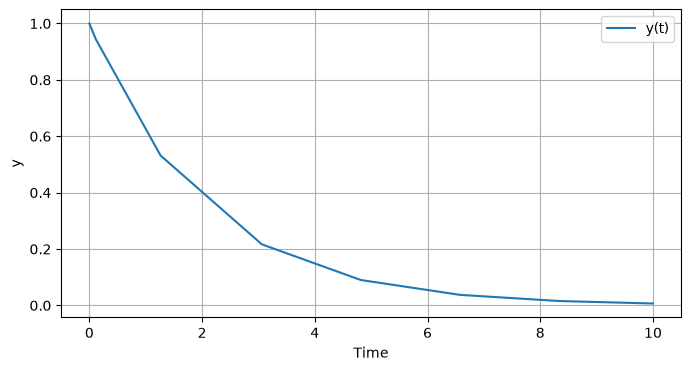

In [5]:
plt.figure(figsize=(8,4))

plt.plot(
    solution.t,
    solution.y[0],
    label="y(t)"
)

plt.xlabel("Time")
plt.ylabel("y")

plt.grid(True)
plt.legend()

plt.show()

## 3. First-order batch reactor

Consider the reaction:

$$
A \rightarrow Products
$$

For a first-order reaction:

$$
-r_A=kC_A
$$

The batch reactor design equation is:

$$
\frac{dC_A}{dt}=-kC_A
$$

Initial condition:

$$
C_A(0)=C_{A0}
$$

In [6]:
k = 0.2
CA0 = 1.0

def batch_first_order(t, CA):

    dCAdt = -k*CA

    return dCAdt

solution = solve_ivp(
    batch_first_order,
    [0,20],
    [CA0],
    t_eval=np.linspace(0,20,200)
)

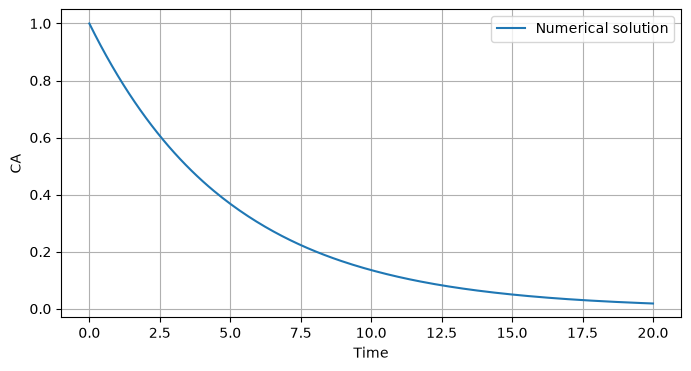

In [7]:
plt.figure(figsize=(8,4))

plt.plot(
    solution.t,
    solution.y[0],
    label="Numerical solution"
)

plt.xlabel("Time")
plt.ylabel("CA")

plt.legend()
plt.grid(True)

plt.show()

## 4. Second-order batch reactor

For:

$$
2A \rightarrow Products
$$

The rate equation:

$$
-r_A=kC_A^2
$$

The ODE becomes:

$$
\frac{dC_A}{dt}=-kC_A^2
$$

In [8]:
k=0.5

def batch_second_order(t, CA):

    dCAdt=-k*CA**2

    return dCAdt

solution2=solve_ivp(
    batch_second_order,
    [0,10],
    [1],
    t_eval=np.linspace(0,10,200)
)

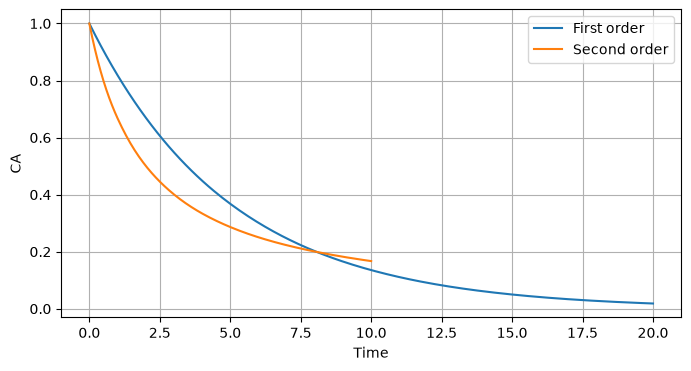

In [9]:
plt.figure(figsize=(8,4))

plt.plot(
    solution.t,
    solution.y[0],
    label="First order"
)

plt.plot(
    solution2.t,
    solution2.y[0],
    label="Second order"
)

plt.xlabel("Time")
plt.ylabel("CA")

plt.legend()
plt.grid(True)

plt.show()

## 5. Dynamic CSTR model

A dynamic CSTR mass balance is:

$$
\frac{dC_A}{dt}
=
\frac{F}{V}(C_{A0}-C_A)
-kC_A
$$

where:

- $F$: volumetric flow rate
- $V$: reactor volume
- $C_{A0}$: inlet concentration
- $C_A$: reactor concentration

In [ ]:
F = 1.0
V = 5.0
CA0 = 1.0
k = 0.3

def cstr_model(t, CA):

    reaction = -k*CA
    flow = (F/V)*(CA0-CA)

    dCAdt = flow + reaction

    return dCAdt

In [11]:
cstr_solution = solve_ivp(
    cstr_model,
    [0,50],
    [0],
    t_eval=np.linspace(0,50,300)
)

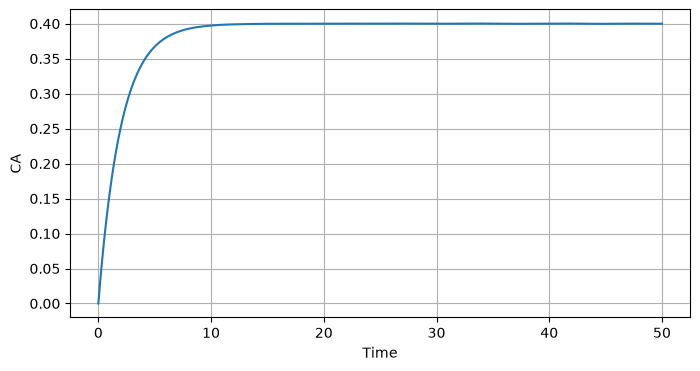

In [12]:
plt.figure(figsize=(8,4))

plt.plot(
    cstr_solution.t,
    cstr_solution.y[0]
)

plt.xlabel("Time")
plt.ylabel("CA")

plt.grid(True)

plt.show()

## 6. Multiple reaction system

Consider consecutive reactions:

$$
A \rightarrow B \rightarrow C
$$

The concentration equations are:

$$
\frac{dC_A}{dt}=-k_1C_A
$$

$$
\frac{dC_B}{dt}=k_1C_A-k_2C_B
$$

$$
\frac{dC_C}{dt}=k_2C_B
$$

In [13]:
k1=0.5
k2=0.2

def reaction_network(t,C):

    CA,CB,CC=C

    dCA=-k1*CA

    dCB=k1*CA-k2*CB

    dCC=k2*CB

    return [
        dCA,
        dCB,
        dCC
    ]

network_solution=solve_ivp(
    reaction_network,
    [0,20],
    [1,0,0],
    t_eval=np.linspace(0,20,200)
)

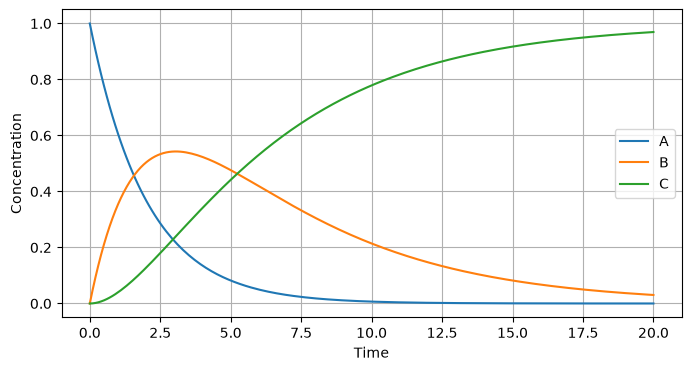

In [14]:
plt.figure(figsize=(8,4))

plt.plot(network_solution.t,
         network_solution.y[0],
         label="A")

plt.plot(network_solution.t,
         network_solution.y[1],
         label="B")

plt.plot(network_solution.t,
         network_solution.y[2],
         label="C")

plt.xlabel("Time")
plt.ylabel("Concentration")

plt.legend()
plt.grid(True)

plt.show()

## 7. Comparing numerical and analytical solutions

For a first-order batch reactor:

Analytical:
$$
C_A=C_{A0}e^{-kt}
$$

Numerical:

Solved using `solve_ivp`.

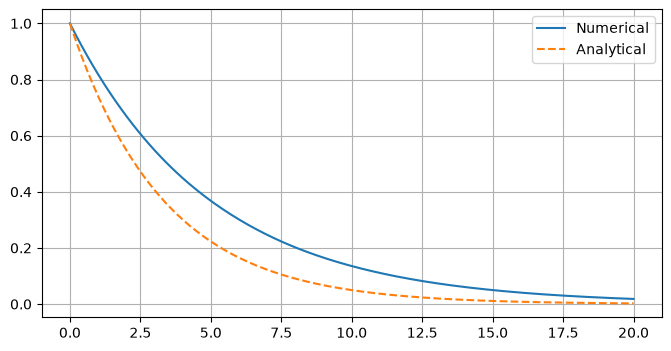

In [15]:
t = solution.t

CA_analytical = CA0*np.exp(-k*t)

plt.figure(figsize=(8,4))

plt.plot(
    t,
    solution.y[0],
    label="Numerical"
)

plt.plot(
    t,
    CA_analytical,
    "--",
    label="Analytical"
)

plt.legend()
plt.grid(True)

plt.show()

## 8. Engineering interpretation

ODE solving allows engineers to:

- predict reactor behavior
- study transient operation
- compare reactor designs
- analyze complex reaction mechanisms

The same numerical framework can later be extended to:

- PFR models
- biochemical reactors
- catalytic reactors
- energy balances

## 9. Summary

In this notebook, you learned:

- why ODEs are important in reaction engineering
- how to use scipy.solve_ivp
- how to model batch reactors
- how to model dynamic CSTR systems
- how to solve reaction networks

These skills are the foundation for reactor design simulations.